# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed that Attack and Defense are positively related. Most Pokemon cluster in the lower-mid range of both attack and defense. Few Pokemon have high values for both, so the upper right part of the plot is pretty sparse. It also looks like low-mid HP Pokemon have stronger attack or defense.
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

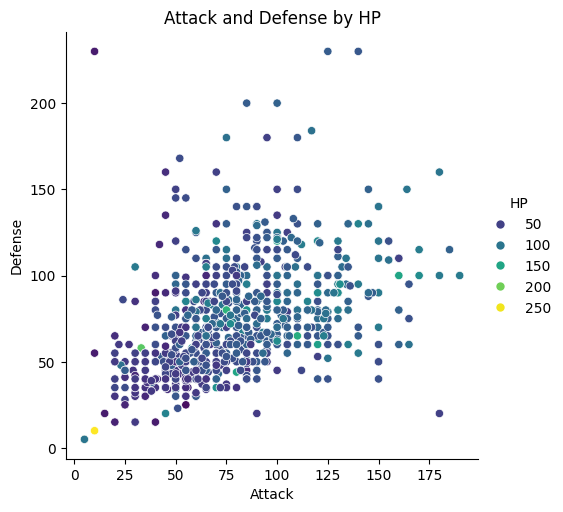

In [3]:
# Your code here . . .
df = pd.read_csv(fp)

sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    kind="scatter",
    palette="viridis"
)

plt.title("Attack and Defense by HP")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.show()

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

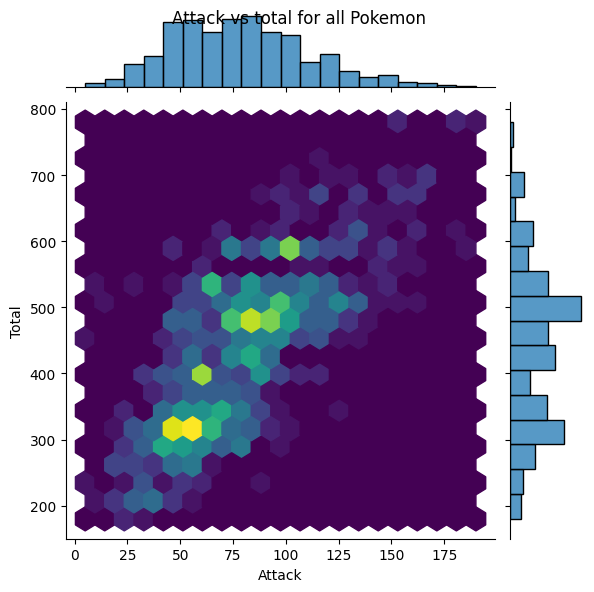

In [9]:
# Your code here . . .
sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=20,
    cmap="viridis"
)

plt.suptitle("Attack vs total for all Pokemon")
plt.show()

From the plot, I observed that Pokemon with higher attack values have higher total stats, meaning that their relationship is positive. The brightest hexagons fall around mid range Attack and mid Range total. High attack and High total is really uncommon. Attack is also concentrated in a moderate range with fewer or very low or very high values and total is clustered around the middle.

Results: Stronger Pokemon have higher total stats.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

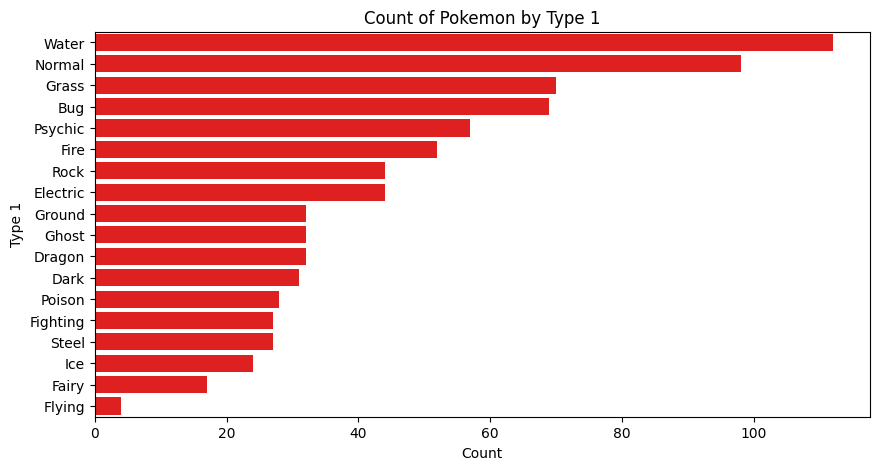

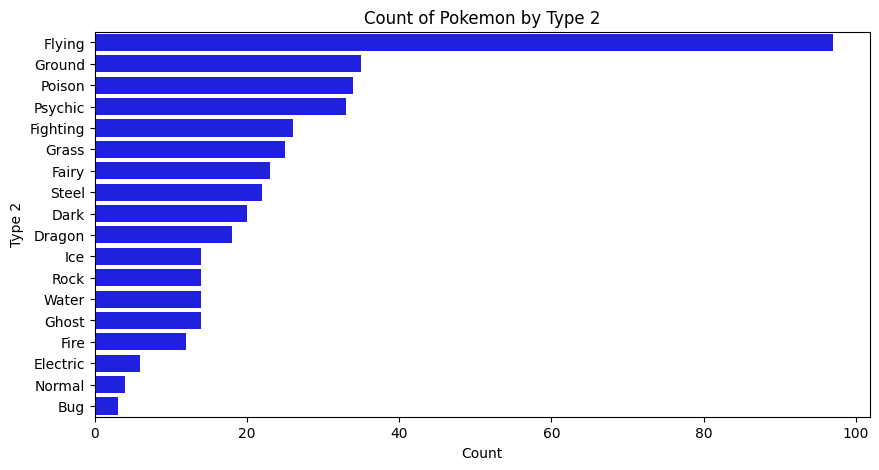

In [11]:
# Your code here . . .
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="Type 1",
    color="red",
    order=df["Type 1"].value_counts().index
)

plt.title("Count of Pokemon by Type 1")
plt.xlabel("Count")
plt.ylabel("Type 1")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="Type 2",
    color="blue",
    order=df["Type 2"].value_counts().index
)

plt.title("Count of Pokemon by Type 2")
plt.xlabel("Count")
plt.ylabel("Type 2")
plt.show()


From the plots, I observed that the most common Type 1 Pokemon are Water, Normal, and Grass, and the most rare are flying and fairy. For type 2, the most common types are flying, ground, and poisin. The rarest types are bug, normal, and electric.

Results: Common primary and secondary types follow distinct frequency patterns

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .
# Question 4: Do Legendary Pokemon have higher defense and attack than non-Legendary ones?

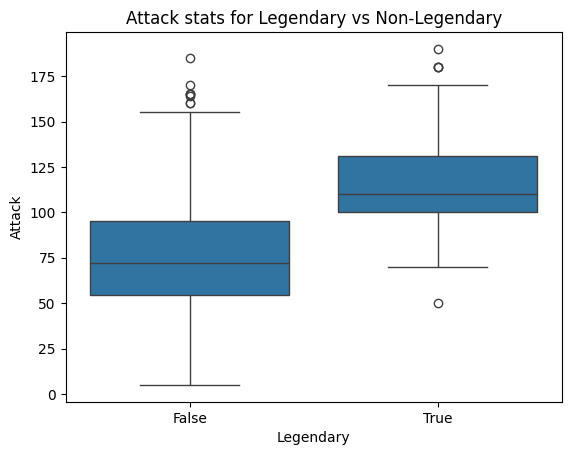

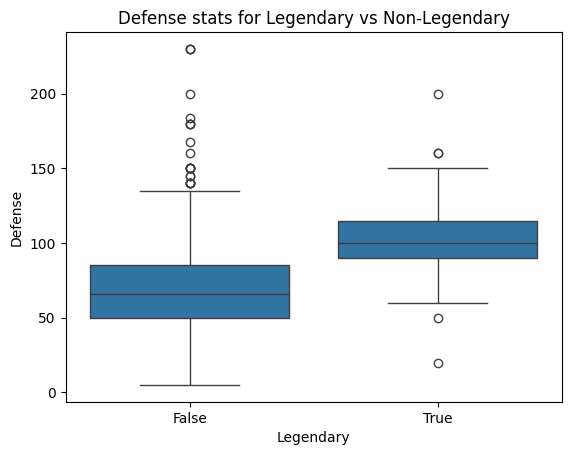

In [12]:
# Your code here . . .
sns.boxplot(
    data=df,
    x="Legendary",
    y="Attack"
)
plt.title("Attack stats for Legendary vs Non-Legendary")
plt.show()

sns.boxplot(
    data=df,
    x="Legendary",
    y="Defense"
)
plt.title("Defense stats for Legendary vs Non-Legendary")
plt.show()

From this plot, I observed that Legendary Pokemon do in fact have both higher defense and attack than non-Legendary Pokemon

Results: Legendaries are stronger than non-Legendaries

# Question 5: How are the total stats for high speed Pokemon?

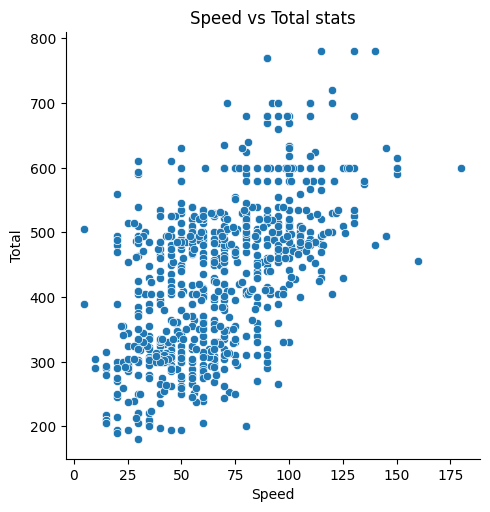

In [13]:
sns.relplot(
    data=df,
    x="Speed",
    y="Total",
    kind="scatter"
)
plt.title("Speed vs Total stats")
plt.show()


From this plot, I observed that Higher speed does not necessarily mean higher total stats. In fact, it looks like lower or mid speed Pokemon have higher total stats that high speed ones

Results: Higher speed does not guarantee higher total stats

# Question 6: Do different Pokemon generations carry different stats?

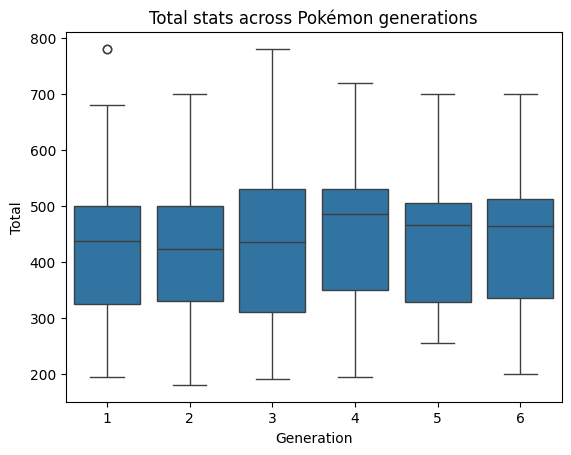

In [14]:
sns.boxplot(
    data=df,
    x="Generation",
    y="Total"
)
plt.title("Total stats across Pokémon generations")
plt.xlabel("Generation")
plt.ylabel("Total")
plt.show()

From this plot, I observed that total stats are pretty similiar across all generations. Generation 1 has an outlier with a high total stat, but everything else looks comparable.

Results: Total stats are similiar across all generations.